<a href="https://colab.research.google.com/github/Axxel135/Classificaton_and_Regression_Diabetes/blob/main/ProyectoSIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>






#ANÁLISIS EXPLORATORIO

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('diabetes_dataset.csv')
display(df.head())

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [3]:
df.shape

(100000, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [5]:
print("Valores nulos por columna:\n", df.isna().sum().sort_values(ascending=False).head(30))
print("DUPLICADOS", df.duplicated().sum())

Valores nulos por columna:
 age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fast

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.120410,15.604600,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.003670,1.417779,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.911640,84.409662,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.994787,1.780954,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,6.997818,1.094622,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,5.996468,2.468406,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.219410,0.413849,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.250800,0.433476,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.079200,0.270052,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.612653,3.586705,15.00,23.20,25.60,28.00,39.20


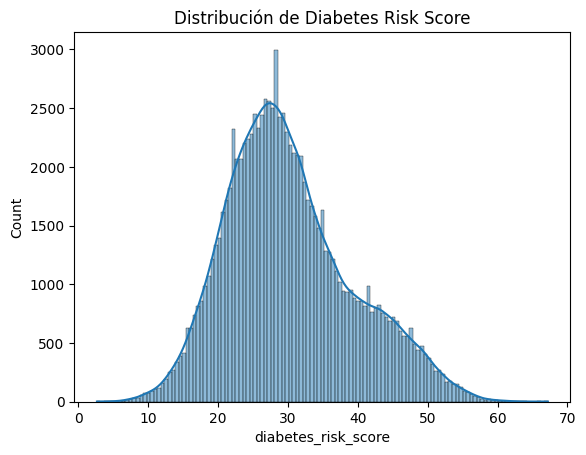

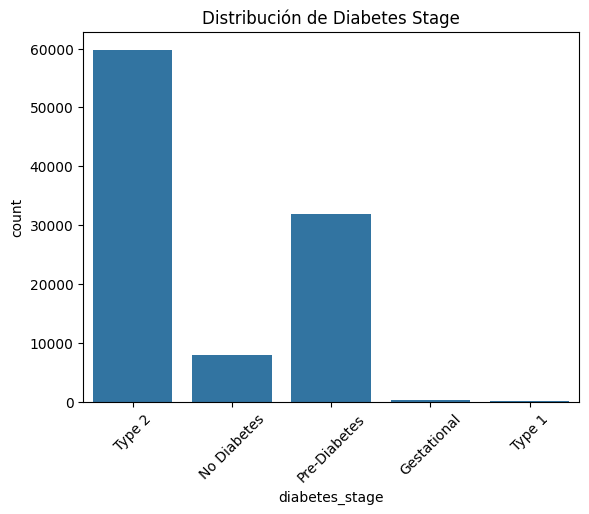

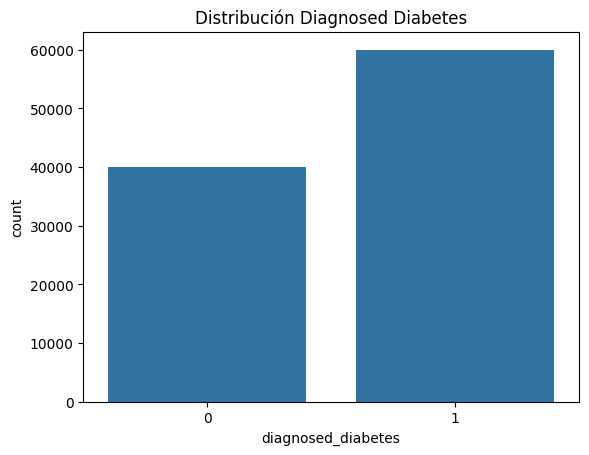

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma del risk score
plt.figure()
sns.histplot(df["diabetes_risk_score"], kde=True)
plt.title("Distribución de Diabetes Risk Score")
plt.show()

# Conteo de clases - diabetes_stage
plt.figure()
sns.countplot(x=df["diabetes_stage"])
plt.title("Distribución de Diabetes Stage")
plt.xticks(rotation=45)
plt.show()

# Conteo binario
plt.figure()
sns.countplot(x=df["diagnosed_diabetes"])
plt.title("Distribución Diagnosed Diabetes")
plt.show()

Correlación de las variables numéricas con 'diabetes_risk_score':


,diabetes_risk_score
diabetes_risk_score,1.000000
family_history_diabetes,0.733085
age,0.495924
glucose_fasting,0.469938
hba1c,0.329947
systolic_bp,0.323591
bmi,0.313813
diagnosed_diabetes,0.277300
glucose_postprandial,0.277041
waist_to_hip_ratio,0.241651


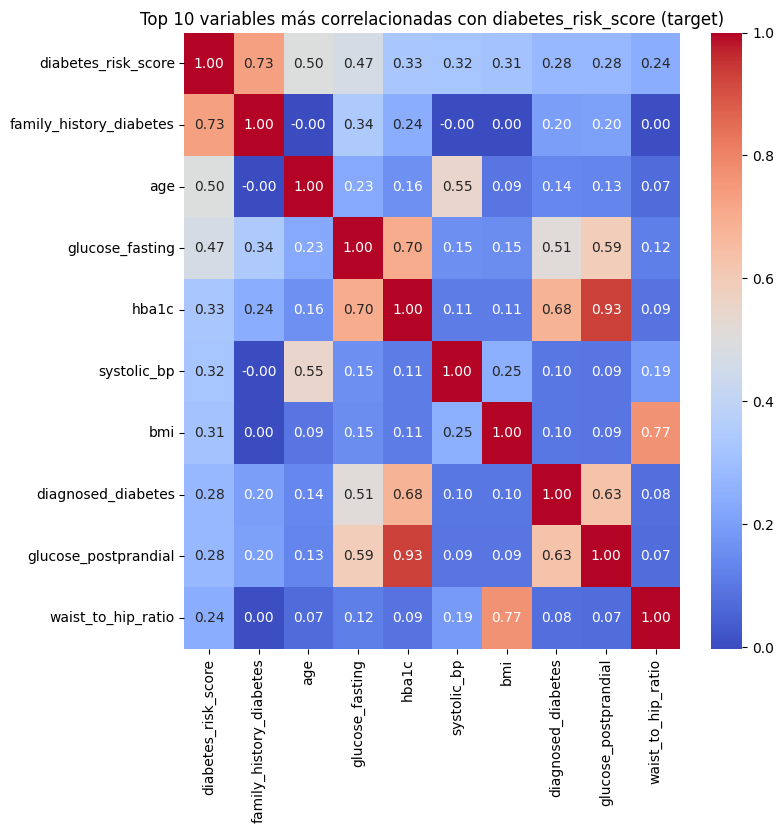

In [8]:
# Calcular la matriz de correlación solo para variables numéricas
correlaciones = df.corr(numeric_only=True)

# Aislar las correlaciones respecto a nuestra variable objetivo (risk score)
corr_con_objetivo = correlaciones['diabetes_risk_score'].sort_values(ascending=False)

# Mostrar en una tabla
print("Correlación de las variables numéricas con 'diabetes_risk_score':")
display(pd.DataFrame(corr_con_objetivo))

# Graficar un mapa de calor con las 10 variables más fuertemente correlacionadas
top_10_vars = corr_con_objetivo.head(10).index
plt.figure(figsize=(8, 8))
sns.heatmap(df[top_10_vars].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 variables más correlacionadas con diabetes_risk_score (target)')
plt.show()

#PREPROCESAMIENTO

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Copia del dataset + OneHot Encoding
columnas_categoricas = [
    'gender', 'ethnicity', 'education_level',
    'income_level', 'employment_status', 'smoking_status'
]

df_procesado = pd.get_dummies(df.copy(), columns=columnas_categoricas, drop_first=True)

# 2. Variables base y targets
X_base = df_procesado.drop(columns=['diabetes_risk_score', 'diabetes_stage', 'diagnosed_diabetes'])
y_clf = df_procesado['diabetes_stage']
y_reg = df_procesado['diabetes_risk_score']

# 3. Split base (estratificado por clasificación)
X_train_base, X_test_base, y_train_clf, y_test_clf = train_test_split(
    X_base, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# 4. Empatar targets de regresión con los mismos índices
y_train_reg = y_reg.loc[X_train_base.index]
y_test_reg = y_reg.loc[X_test_base.index]

# 5. Definir columnas numéricas
columnas_numericas = [
    'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week',
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day',
    'family_history_diabetes', 'hypertension_history', 'cardiovascular_history',
    'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides',
    'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c'
]

# 6. Crear versiones escaladas SIN tocar la base original
scaler = StandardScaler()

X_train_scaled = X_train_base.copy()
X_test_scaled = X_test_base.copy()

X_train_scaled[columnas_numericas] = scaler.fit_transform(X_train_base[columnas_numericas])
X_test_scaled[columnas_numericas] = scaler.transform(X_test_base[columnas_numericas])

print("Split base y versiones escaladas listos.")
print(f"X_train_base: {X_train_base.shape}")
print(f"X_test_base: {X_test_base.shape}")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

Split base y versiones escaladas listos.
X_train_base: (80000, 40)
X_test_base: (20000, 40)
X_train_scaled: (80000, 40)
X_test_scaled: (20000, 40)


# MODELO DE REGRESIÓN

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [11]:
print("=== REGRESIÓN ===")

# ----------------------
# 1. Linear Regression (con datos escalados)
# ----------------------
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)

y_pred_lr = lr.predict(X_test_scaled)

# Métricas
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("\nLinear Regression:")
print(f"MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R2: {r2_lr:.4f}")

=== REGRESIÓN ===

Linear Regression:
MAE: 0.4387
RMSE: 0.7679
R2: 0.9927


In [12]:
# ----------------------
# 2. Random Forest (SIN escalar)
# ----------------------
rf_reg = RandomForestRegressor(random_state=42, n_estimators=100)
rf_reg.fit(X_train_base, y_train_reg)

y_pred_rf_reg = rf_reg.predict(X_test_base)

# Métricas
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf_reg)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

print("\nRandom Forest:")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2: {r2_rf:.4f}")


Random Forest:
MAE: 0.6272
RMSE: 0.8248
R2: 0.9916


In [13]:
print(y_clf.value_counts())
print("\nProporciones:")
print(y_clf.value_counts(normalize=True))

diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64

Proporciones:
diabetes_stage
Type 2          0.59774
Pre-Diabetes    0.31845
No Diabetes     0.07981
Gestational     0.00278
Type 1          0.00122
Name: proportion, dtype: float64


In [14]:
#Creamos un modelo que NO aprende para después poder compararlo con los modelos reales
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

print("=== BASELINE CLASIFICACIÓN ===")

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_base, y_train_clf)

y_pred_dummy = dummy.predict(X_test_base)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_dummy))
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_dummy))

=== BASELINE CLASIFICACIÓN ===
Accuracy: 0.59775

Classification Report:
              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        56
 No Diabetes       0.00      0.00      0.00      1596
Pre-Diabetes       0.00      0.00      0.00      6369
      Type 1       0.00      0.00      0.00        24
      Type 2       0.60      1.00      0.75     11955

    accuracy                           0.60     20000
   macro avg       0.12      0.20      0.15     20000
weighted avg       0.36      0.60      0.45     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#MODELO DE CLASIFICACIÓN

##LOGISTIC REGRESSION

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

print("=== Logistic Regression (balanced) ===")

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')

# IMPORTANTE: usar datos escalados
log_reg.fit(X_train_scaled, y_train_clf)

y_pred_log = log_reg.predict(X_test_scaled)

print("Balanced Accuracy:", balanced_accuracy_score(y_test_clf, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_log))

=== Logistic Regression (balanced) ===
Balanced Accuracy: 0.5902735811026908

Classification Report:
              precision    recall  f1-score   support

 Gestational       0.01      0.50      0.02        56
 No Diabetes       0.65      0.83      0.73      1596
Pre-Diabetes       0.76      0.58      0.66      6369
      Type 1       0.00      0.38      0.01        24
      Type 2       0.94      0.67      0.78     11955

    accuracy                           0.65     20000
   macro avg       0.47      0.59      0.44     20000
weighted avg       0.86      0.65      0.73     20000



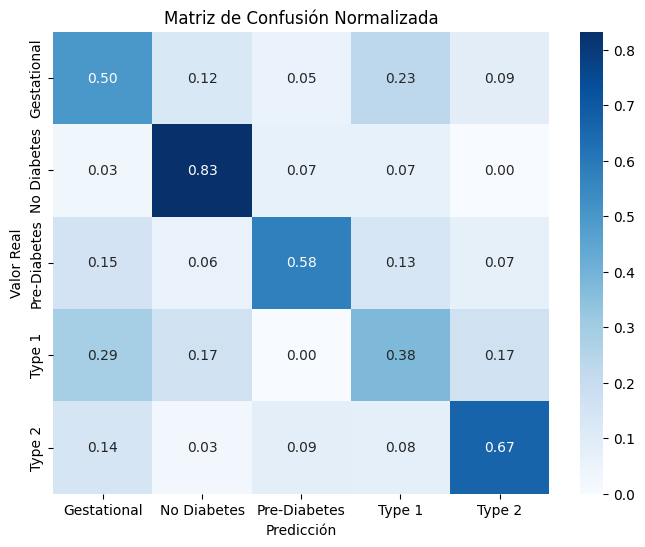

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = sorted(y_test_clf.unique())

cm_norm = confusion_matrix(y_test_clf, y_pred_log, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión Normalizada")
plt.show()

In [17]:
y_clf_grouped = y_clf.copy()

y_clf_grouped = y_clf_grouped.replace({
    'Type 1': 'Other',
    'Gestational': 'Other'
})

In [18]:
print(y_clf_grouped.value_counts())
print("\nProporciones:")
print(y_clf_grouped.value_counts(normalize=True))

diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Other             400
Name: count, dtype: int64

Proporciones:
diabetes_stage
Type 2          0.59774
Pre-Diabetes    0.31845
No Diabetes     0.07981
Other           0.00400
Name: proportion, dtype: float64


In [19]:
X_train_grp, X_test_grp, y_train_grp, y_test_grp = train_test_split(
    X_base, y_clf_grouped,
    test_size=0.2,
    random_state=42,
    stratify=y_clf_grouped
)

In [20]:
X_train_grp_scaled = X_train_grp.copy()
X_test_grp_scaled = X_test_grp.copy()

X_train_grp_scaled[columnas_numericas] = scaler.fit_transform(X_train_grp[columnas_numericas])
X_test_grp_scaled[columnas_numericas] = scaler.transform(X_test_grp[columnas_numericas])

In [21]:
print(y_train_grp.value_counts(normalize=True))
print(y_test_grp.value_counts(normalize=True))

diabetes_stage
Type 2          0.597738
Pre-Diabetes    0.318450
No Diabetes     0.079812
Other           0.004000
Name: proportion, dtype: float64
diabetes_stage
Type 2          0.59775
Pre-Diabetes    0.31845
No Diabetes     0.07980
Other           0.00400
Name: proportion, dtype: float64


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

print("=== Logistic Regression (Grouped Target) ===")

log_reg_grp = LogisticRegression(max_iter=1000, class_weight='balanced')

# usar datos escalados
log_reg_grp.fit(X_train_grp_scaled, y_train_grp)

y_pred_grp = log_reg_grp.predict(X_test_grp_scaled)

print("Balanced Accuracy:", balanced_accuracy_score(y_test_grp, y_pred_grp))

print("\nClassification Report:")
print(classification_report(y_test_grp, y_pred_grp))

=== Logistic Regression (Grouped Target) ===
Balanced Accuracy: 0.6986652336973854

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.66      0.89      0.76      1596
       Other       0.01      0.53      0.02        80
Pre-Diabetes       0.77      0.66      0.71      6369
      Type 2       0.95      0.72      0.82     11955

    accuracy                           0.71     20000
   macro avg       0.60      0.70      0.58     20000
weighted avg       0.87      0.71      0.78     20000



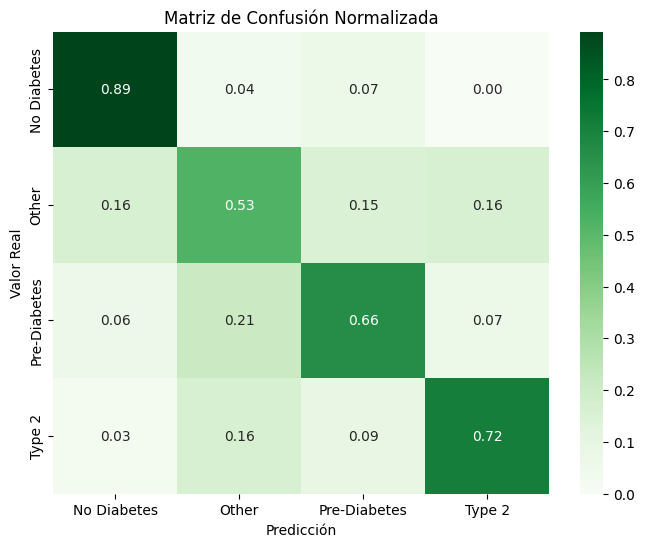

In [23]:
labels_grp = sorted(y_test_grp.unique())

cm_norm = confusion_matrix(y_test_grp, y_pred_grp, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=labels_grp,
            yticklabels=labels_grp)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión Normalizada")
plt.show()

In [24]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

comparacion_clf = pd.DataFrame({
    'Modelo': ['Original Target', 'Grouped Target'],
    'Accuracy': [
        accuracy_score(y_test_clf, y_pred_log),
        accuracy_score(y_test_grp, y_pred_grp)
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test_clf, y_pred_log),
        balanced_accuracy_score(y_test_grp, y_pred_grp)
    ],
    'F1 Macro': [
        f1_score(y_test_clf, y_pred_log, average='macro'),
        f1_score(y_test_grp, y_pred_grp, average='macro')
    ],
    'F1 Weighted': [
        f1_score(y_test_clf, y_pred_log, average='weighted'),
        f1_score(y_test_grp, y_pred_grp, average='weighted')
    ]
})


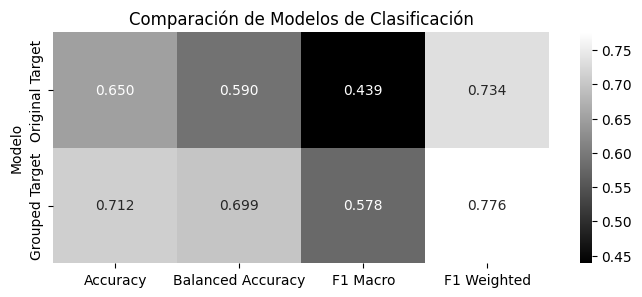

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))
sns.heatmap(
    comparacion_clf.set_index('Modelo'),
    annot=True,
    cmap='gray',
    fmt='.3f'
)

plt.title("Comparación de Modelos de Clasificación")
plt.show()

##RANDOM FOREST

In [26]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

In [27]:
rf_clf = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_clf.fit(X_train_grp, y_train_grp)

y_pred_rf_grp = rf_clf.predict(X_test_grp)

print("=== Random Forest (Grouped Target) ===")

print("Balanced Accuracy:", balanced_accuracy_score(y_test_grp, y_pred_rf_grp))

print("\nClassification Report:")
print(classification_report(y_test_grp, y_pred_rf_grp))

=== Random Forest (Grouped Target) ===
Balanced Accuracy: 0.7439051402328523

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.84      1.00      0.91      1596
       Other       0.01      0.30      0.03        80
Pre-Diabetes       0.81      0.93      0.87      6369
      Type 2       1.00      0.75      0.85     11955

    accuracy                           0.82     20000
   macro avg       0.67      0.74      0.66     20000
weighted avg       0.92      0.82      0.86     20000



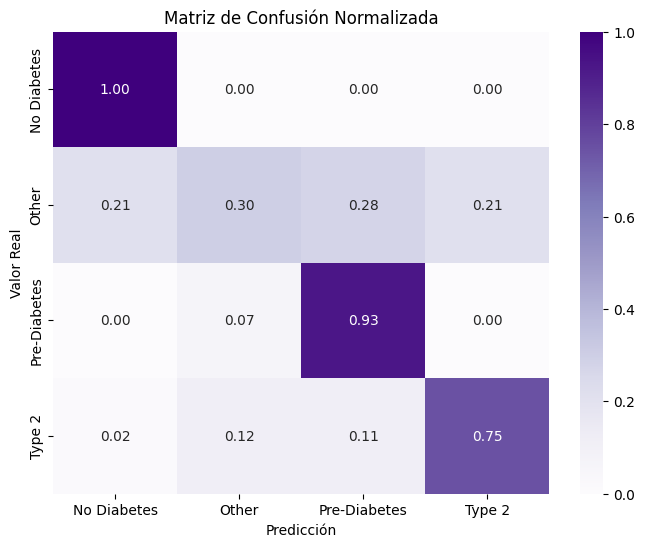

In [28]:
labels_rf = sorted(y_test_grp.unique())

cm_norm = confusion_matrix(y_test_grp, y_pred_rf_grp, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=labels_rf,
            yticklabels=labels_rf)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión Normalizada")
plt.show()

In [29]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
import pandas as pd

comparacion_final = pd.DataFrame({
    'Modelo': [
        'Logistic (Original)',
        'Logistic (Grouped)',
        'Random Forest (Grouped)'
    ],
    'Accuracy': [
        accuracy_score(y_test_clf, y_pred_log),
        accuracy_score(y_test_grp, y_pred_grp),
        accuracy_score(y_test_grp, y_pred_rf_grp)
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test_clf, y_pred_log),
        balanced_accuracy_score(y_test_grp, y_pred_grp),
        balanced_accuracy_score(y_test_grp, y_pred_rf_grp)
    ],
    'F1 Macro': [
        f1_score(y_test_clf, y_pred_log, average='macro'),
        f1_score(y_test_grp, y_pred_grp, average='macro'),
        f1_score(y_test_grp, y_pred_rf_grp, average='macro')
    ],
    'F1 Weighted': [
        f1_score(y_test_clf, y_pred_log, average='weighted'),
        f1_score(y_test_grp, y_pred_grp, average='weighted'),
        f1_score(y_test_grp, y_pred_rf_grp, average='weighted')
    ]
})

# Redondear para presentación
comparacion_final = comparacion_final.sort_values(by='Balanced Accuracy', ascending=False)

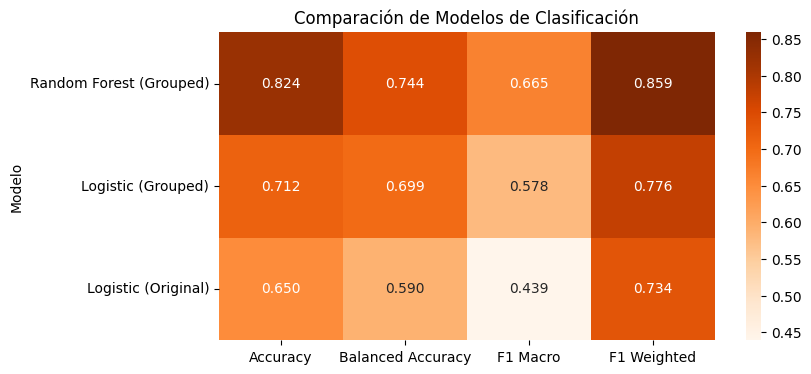

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(
    comparacion_final.set_index('Modelo'),
    annot=True,
    cmap='Oranges',
    fmt='.3f'
)

plt.title("Comparación de Modelos de Clasificación")
plt.show()

##CLUSTERING

In [31]:
from sklearn.preprocessing import StandardScaler

# Datos para clustering sin targets
X_cluster = X_base.copy()

# Escalamos porque medimos distancias
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Shape original:", X_cluster.shape)
print("Shape escalado:", X_cluster_scaled.shape)

Shape original: (100000, 40)
Shape escalado: (100000, 40)


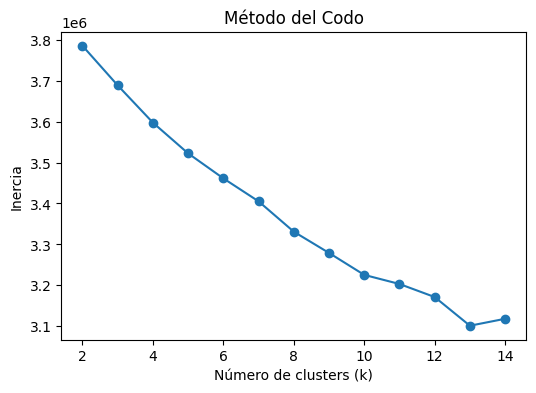

In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

k_values = range(2, 15)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_values, inercia, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

In [37]:
import numpy as np

# tomar muestra de 10,000 (si entrenáramos con todos los datos es mucho gasto computacionalmente)
sample_size = 10000

idx = np.random.choice(X_cluster_scaled.shape[0], sample_size, replace=False)
X_sample = X_cluster_scaled[idx]

In [35]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []
k_values = range(2, 15)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)

for k, score in zip(k_values, silhouette_scores):
    print(f"k={k}: {score:.4f}")

k=2: 0.0528
k=3: 0.0417
k=4: 0.0453
k=5: 0.0487
k=6: 0.0433
k=7: 0.0482
k=8: 0.0484
k=9: 0.0533
k=10: 0.0521
k=11: 0.0478
k=12: 0.0422
k=13: 0.0423
k=14: 0.0382


In [38]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=7, random_state=42, n_init=10)

clusters = kmeans_final.fit_predict(X_cluster_scaled)

In [40]:
df_cluster = df_procesado.copy()
df_cluster['cluster'] = clusters

print(df_cluster['cluster'].value_counts())

cluster
3    23943
4    17386
5    15586
2    13240
6    12682
1    12118
0     5045
Name: count, dtype: int64


In [45]:
#Checamos cómo repartió diabetes_stage en los cluster
tabla = pd.crosstab(
    df_cluster['cluster'],
    df['diabetes_stage'],
    normalize='index'
) * 100

tabla = tabla.round(2)
tabla.style.format("{:.2f}%")

diabetes_stage,Gestational,No Diabetes,Pre-Diabetes,Type 1,Type 2
cluster,,,,,
0,0.36%,8.03%,31.06%,0.12%,60.44%
1,0.32%,9.00%,37.11%,0.14%,53.42%
2,0.26%,9.26%,36.19%,0.14%,54.15%
3,0.34%,15.10%,45.58%,0.21%,38.77%
4,0.15%,3.35%,31.99%,0.04%,64.47%
5,0.26%,0.00%,1.23%,0.08%,98.43%
6,0.30%,8.37%,34.10%,0.09%,57.15%


In [46]:
#Veamos gráficamente la distribución
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_scaled)

In [47]:
import pandas as pd

df_viz = pd.DataFrame()
df_viz['PC1'] = X_pca[:, 0]
df_viz['PC2'] = X_pca[:, 1]
df_viz['cluster'] = clusters

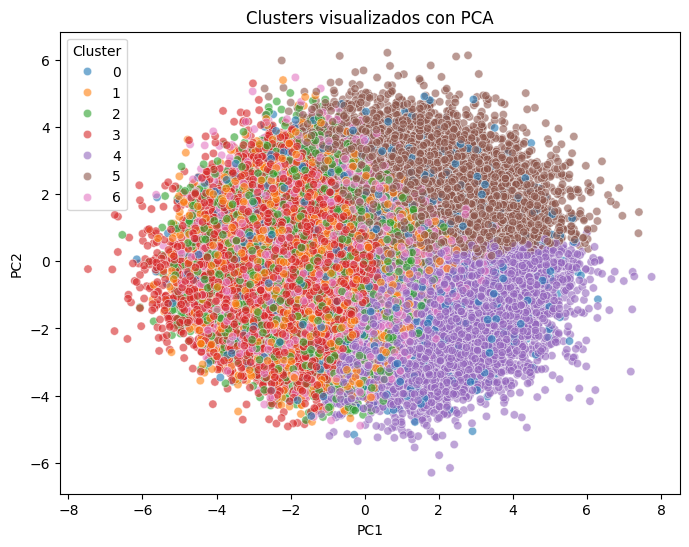

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_viz,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    alpha=0.6
)

plt.title("Clusters visualizados con PCA")
plt.legend(title="Cluster")
plt.show()

In [54]:
#Veremos el promedio de variables por cada cluster (sólo variables numéricas)
#Como son muchísimas variables, sólo se tomarán las más importantes clínicamente
perfil_clusters = df_cluster.groupby('cluster').mean(numeric_only=True)
perfil_clusters = perfil_clusters.round(2)

variables_clave = [
    'age',
    'bmi',
    'glucose_fasting',
    'hba1c',
    'insulin_level',
    'cholesterol_total',
    'triglycerides'
]

perfil_reducido = perfil_clusters[variables_clave]

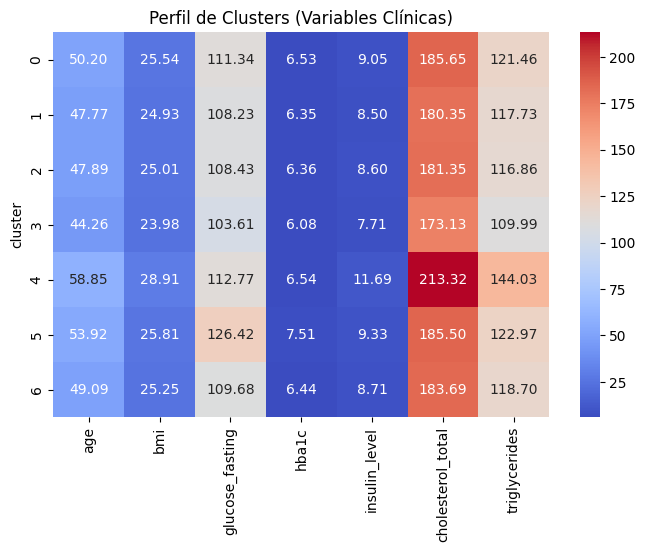

In [53]:
plt.figure(figsize=(8,5))

sns.heatmap(
    perfil_reducido,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Perfil de Clusters (Variables Clínicas)")
plt.show()